### **BANK LOAN ANALYSIS REPORT** ###

### **Impact Required libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

### **Import the Datasets**

In [5]:
df = pd.read_excel('/content/financial_loan_data_excel.xlsx')

In [20]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [21]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679



### **Metadata of data**

In [22]:
print("No of Rows:",df.shape[0])
print("No of columns",df.shape[1])

No of Rows: 38576
No of columns 24


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

### **DataTypes**

In [24]:
df.dtypes
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### **Total Loan Application**

In [25]:
total_loan_application = df['id'].count()
print("Total Loan Apllication:",total_loan_application)

Total Loan Apllication: 38576


### **MTD Total Loan Application**

In [26]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_data_application = mtd_data['id'].count()
print(f"MTD Loan Application (for {latest_issue_date.strftime('%B %Y')}):{mtd_data_application}")


MTD Loan Application (for December 2021):4314


### **Total Funded Amount**


In [27]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount = total_funded_amount/1000000
print("Total Funded Amount:${:.2f}M".format(total_funded_amount))

Total Funded Amount:$435.76M


### **MTD Total Funded Amount**

In [28]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_millions = mtd_total_funded_amount / 1000000
print("Total Funded Amount:${:.2f}M".format(mtd_total_funded_millions))


Total Funded Amount:$53.98M


### **Total Amount Recieved**

In [29]:
total_amount_recieved = df['total_payment'].sum()
total_amount_recieved_millions = total_amount_recieved/1000000
print("Total Amount Recieved:${:.2f}M".format(total_amount_recieved_millions))


Total Amount Recieved:$473.07M


### **MTD Total Amount Recieved**

In [30]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_total_amount_recieved = mtd_data['total_payment'].sum()
mtd_total_amount_recieved_millions = mtd_total_amount_recieved / 1000000
print("Total Amount Recieved:${:.2f}M".format(mtd_total_amount_recieved_millions))

Total Amount Recieved:$58.07M


### **Average Interest Rate**

In [31]:
average_interest_rate = df['int_rate'].mean()*100
print("Avg Int Rate:{:.2f}%".format(average_interest_rate))

Avg Int Rate:12.05%


### **Average debt-to-income-Ratio (DTI)**

In [32]:
average_dti = df['dti'].mean()*100
print("Avg Dti:{:.2f}%".format(average_dti))

Avg Dti:13.33%


### **Good Loan Metrices**

In [33]:
good_loans = df[df['loan_status'].isin(["Fully Paid","current"])]
total_loan_application = df['id'].count()
good_loan_application = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_recieved_amount = good_loans['total_payment'].sum()
good_loan_funded_amount_millions = good_loan_funded_amount/1000000
good_loan_recieved_amount_millions = good_loan_recieved_amount/1000000
good_loan_percentage = (good_loan_application / total_loan_application)*100

print("Good Loan Application:",good_loan_application)
print("Good Loan Funded Amount(in millions):${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Recieved Amount(in millions):${:.2f}M".format(good_loan_recieved_amount_millions))
print("Percentage of Good Loan Application:{:.2f}M".format(good_loan_percentage))


Good Loan Application: 32145
Good Loan Funded Amount(in millions):$351.36M
Good Loan Recieved Amount(in millions):$411.59M
Percentage of Good Loan Application:83.33M


### **Bad Loan Amount**

In [34]:
bad_loans = df[df['loan_status'].isin(["charged Off "])]
total_loan_application = df['id'].count()
bad_loan_application = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_recieved_amount = bad_loans['total_payment'].sum()
bad_loan_funded_amount_millions = good_loan_funded_amount/1000000
bad_loan_recieved_amount_millions = good_loan_recieved_amount/1000000
bad_loan_percentage = (good_loan_application / total_loan_application)*100

print("Bad Loan Application:",good_loan_application)
print("Bad Loan Funded Amount(in millions):${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Recieved Amount(in millions):${:.2f}M".format(bad_loan_recieved_amount_millions))
print("Percentage of Bad Loan Application:{:.2f}M".format(bad_loan_percentage))

Bad Loan Application: 32145
Bad Loan Funded Amount(in millions):$351.36M
Bad Loan Recieved Amount(in millions):$411.59M
Percentage of Bad Loan Application:83.33M


### **CHARTS**

### **Monthly Trend by Issue Date for Total Funded Amount**

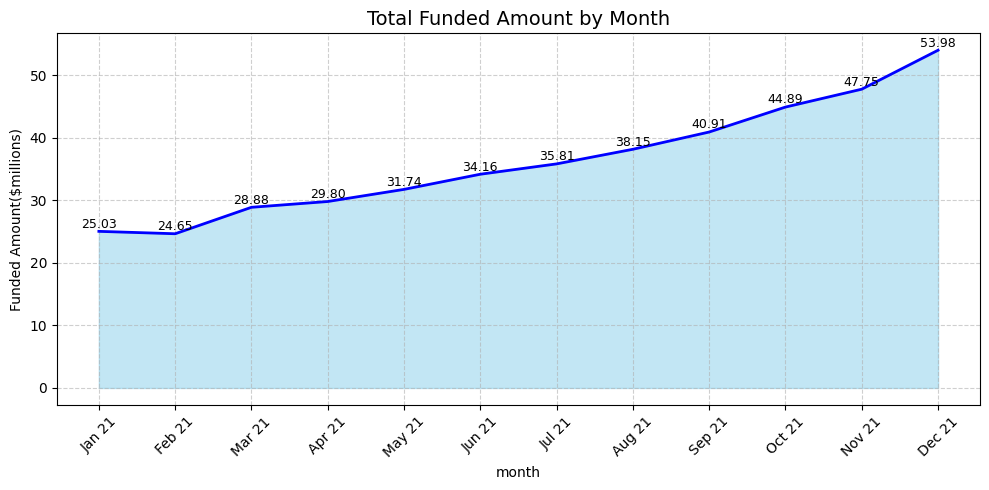

In [35]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %y'))
      .groupby('month_name',sort = False)['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name = 'loan_amount_millions')
 )
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color = 'skyblue',alpha = 0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color = 'blue',linewidth = 2)
for i, row in monthly_funded.iterrows():
  plt.text(i, row['loan_amount_millions']+ 0.1, f"{row['loan_amount_millions']:.2f}",
           ha = 'center', va = 'bottom', fontsize = 9, rotation = 0,color = 'black')
plt.title('Total Funded Amount by Month',fontsize = 14)
plt.xlabel('month')
plt.ylabel('Funded Amount($millions)')
plt.xticks(ticks = range(len(monthly_funded)),labels = monthly_funded['month_name'],rotation = 45)
plt.grid(True, linestyle = '--',alpha = 0.6)
plt.tight_layout()
plt.show()




### **Monthly Trend by Issue Date for Total Amount Recieved**

> Add blockquote



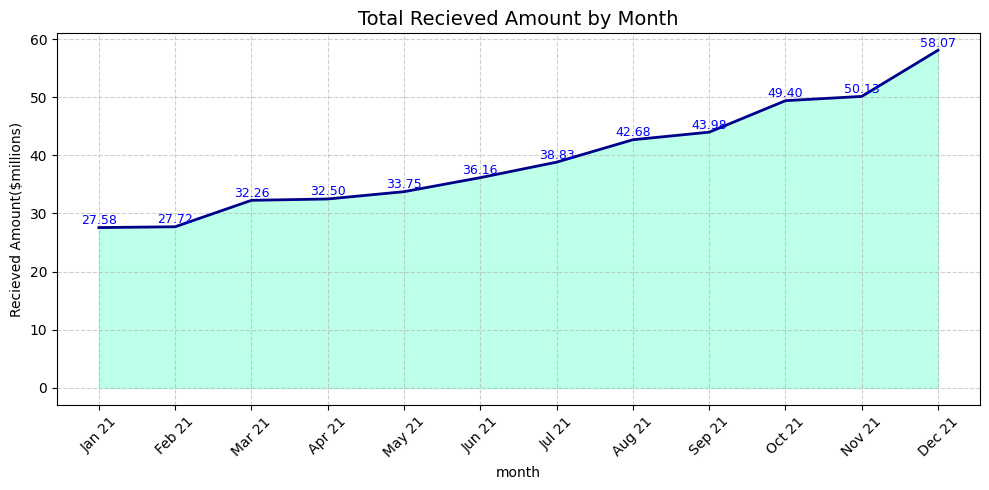

In [57]:
monthly_recieved = (
    df.sort_values('issue_date')
      .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %y'))
      .groupby('month_name',sort = False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name = 'recieved_amount_millions')
 )
plt.figure(figsize=(10,5))
plt.fill_between(monthly_recieved['month_name'],monthly_recieved['recieved_amount_millions'],color = 'aquamarine',alpha = 0.5)
plt.plot(monthly_recieved['month_name'],monthly_recieved['recieved_amount_millions'],color = 'darkblue',linewidth = 2)
for i, row in monthly_recieved.iterrows():
  plt.text(i, row['recieved_amount_millions']+ 0.1, f"{row['recieved_amount_millions']:.2f}",
           ha = 'center', va = 'bottom', fontsize = 9, rotation = 0,color = 'blue')
plt.title('Total Recieved Amount by Month',fontsize = 14)
plt.xlabel('month')
plt.ylabel('Recieved Amount($millions)')
plt.xticks(ticks = range(len(monthly_recieved)),labels = monthly_recieved['month_name'],rotation = 45)
plt.grid(True, linestyle = '--',alpha = 0.6)
plt.tight_layout()
plt.show()

### **Monthly Trend by Issue Date for Total Loan Application**

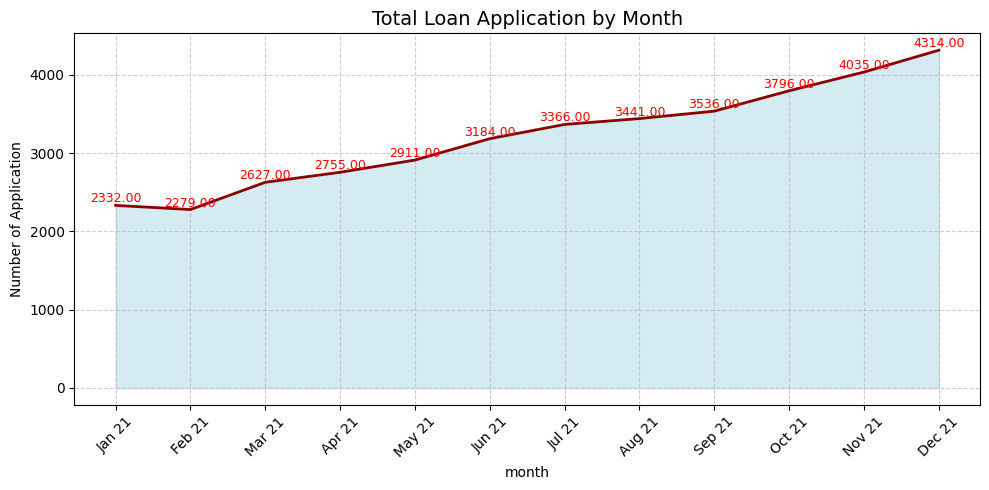

In [54]:
monthly_application = (
    df.sort_values('issue_date')
      .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %y'))
      .groupby('month_name',sort = False)['id']
      .count()
      .reset_index(name = 'loan_application_count')
 )
plt.figure(figsize=(10,5))
plt.fill_between(monthly_application['month_name'],monthly_application['loan_application_count'],color = 'lightblue',alpha = 0.5)
plt.plot(monthly_application['month_name'],monthly_application['loan_application_count'],color = 'darkred',linewidth = 2)
for i, row in monthly_application.iterrows():
  plt.text(i, row['loan_application_count']+ 0.1, f"{row['loan_application_count']:.2f}",
           ha = 'center', va = 'bottom', fontsize = 9, rotation = 0,color = 'red')
plt.title('Total Loan Application by Month',fontsize = 14)
plt.xlabel('month')
plt.ylabel('Number of Application')
plt.xticks(ticks = range(len(monthly_application)),labels = monthly_application['month_name'],rotation = 45)
plt.grid(True, linestyle = '--',alpha = 0.6)
plt.tight_layout()
plt.show()

### **Regional Analysis by State of Total Funded Amount**

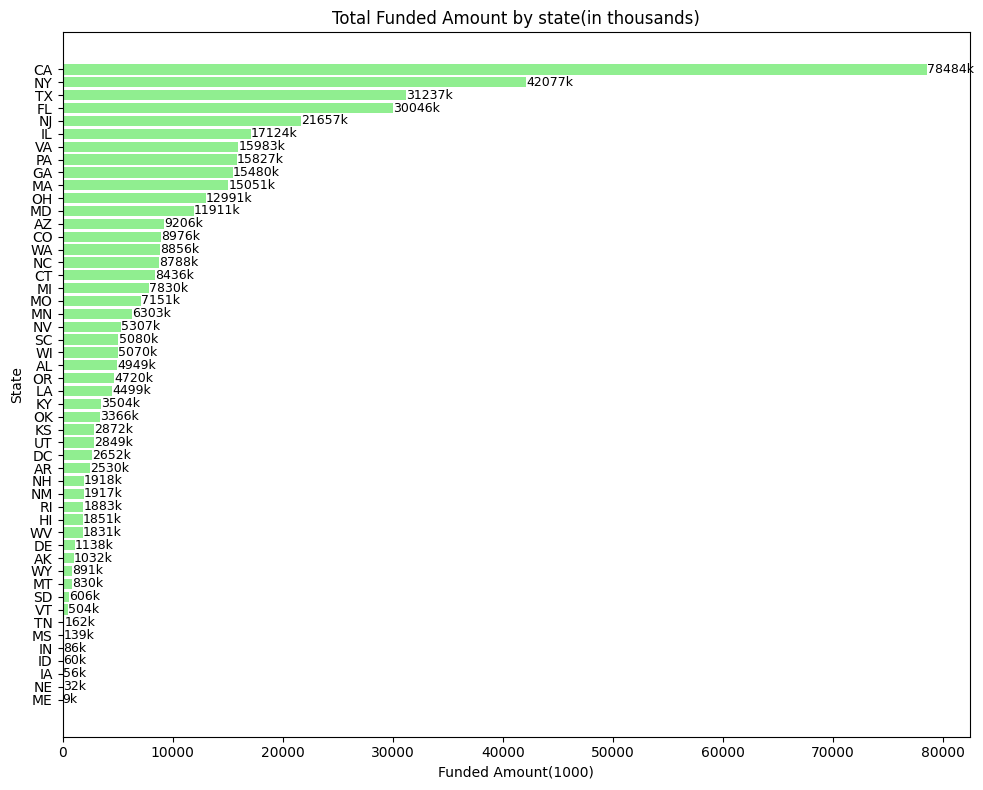

In [ ]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending = True)
state_funding_thousands = state_funding/1000
plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index,state_funding_thousands.values,color = 'lightgreen')
for bar in bars:
  width = bar.get_width()
  plt.text(width+10,bar.get_y()+bar.get_height()/2,f'{width:.0f}k',va = 'center',fontsize = 9)
plt.title('Total Funded Amount by state(in thousands)')
plt.xlabel('Funded Amount(1000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### **Regional Analysis by State of Total Amount Recieved**

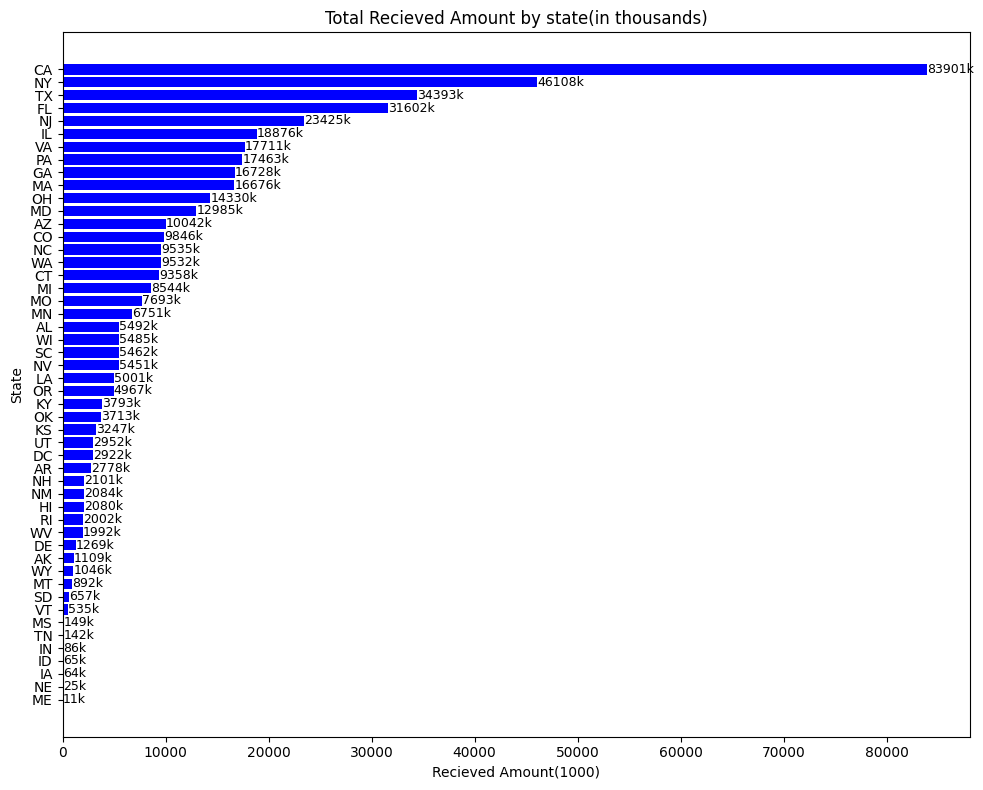

In [32]:
state_funding = df.groupby('address_state')['total_payment'].sum().sort_values(ascending = True)
state_funding_thousands = state_funding/1000
plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index,state_funding_thousands.values,color = 'blue')
for bar in bars:
  width = bar.get_width()
  plt.text(width+10,bar.get_y()+bar.get_height()/2,f'{width:.0f}k',va = 'center',fontsize = 9)
plt.title('Total Recieved Amount by state(in thousands)')
plt.xlabel('Recieved Amount(1000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### **Regional Analysis by State of Total Loan Application** ###

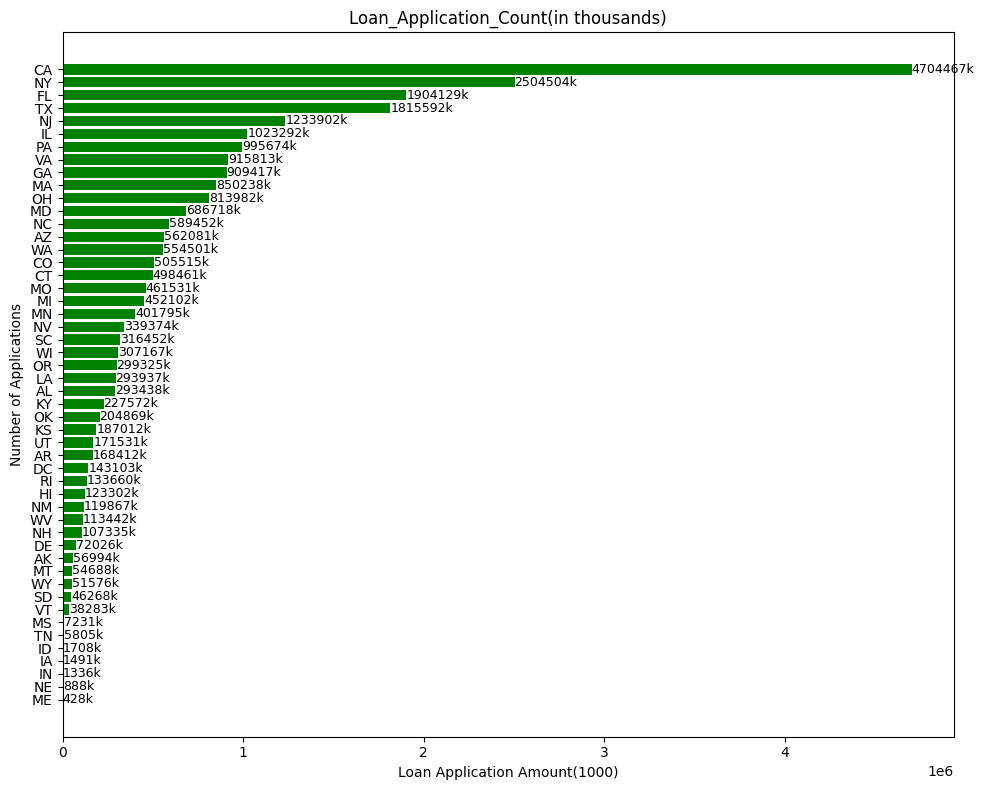

In [31]:
state_funding = df.groupby('address_state')['id'].sum().sort_values(ascending = True)
state_funding_thousands = state_funding/1000
plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index,state_funding_thousands.values,color = 'green')
for bar in bars:
  width = bar.get_width()
  plt.text(width+10,bar.get_y()+bar.get_height()/2,f'{width:.0f}k',va = 'center',fontsize = 9)
plt.title('Loan_Application_Count(in thousands)')
plt.xlabel('Loan Application Amount(1000)')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

### **Loan Term Analysis by Total Funded Amount**

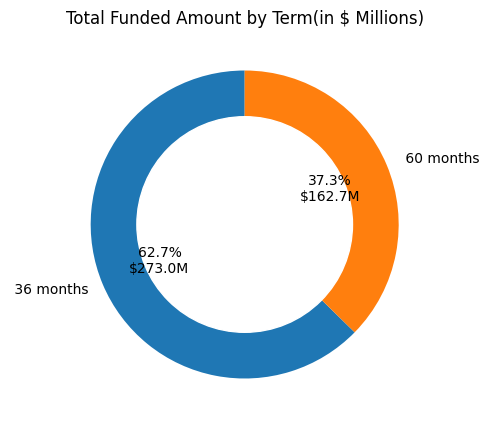

In [34]:
term_funding_millions = df.groupby('term')['loan_amount'].sum()/1000000
plt.figure(figsize=(5,5))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct = lambda p : f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",startangle = 90,wedgeprops = {'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color = 'white'))
plt.title("Total Funded Amount by Term(in $ Millions)")
plt.show()


### **Loan Term Analysis by Total Amount Received** ###

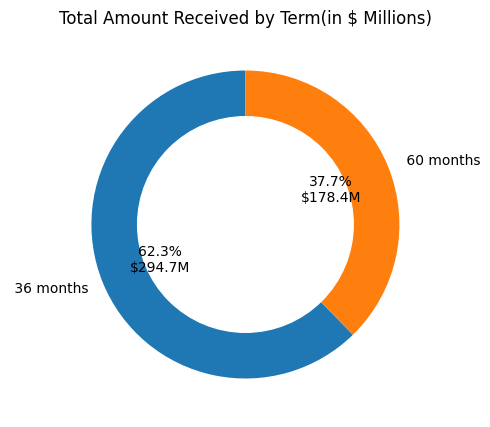

In [36]:
term_Amount_Recieved_millions = df.groupby('term')['total_payment'].sum()/1000000
plt.figure(figsize=(5,5))
plt.pie(
    term_Amount_Recieved_millions,
    labels = term_Amount_Recieved_millions.index,
    autopct = lambda p : f"{p:.1f}%\n${p*sum(term_Amount_Recieved_millions)/100:.1f}M",startangle = 90,wedgeprops = {'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color = 'white'))
plt.title("Total Amount Received by Term(in $ Millions)")
plt.show()

### **Loan Term Analysis by Total Loan Application** ###

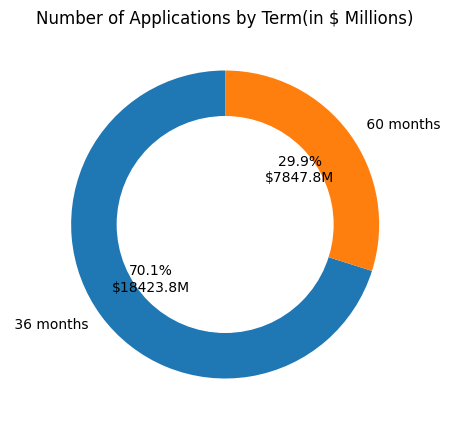

In [14]:
term_Loan_Application_millions = df.groupby('term')['id'].sum()/1000000
plt.figure(figsize=(5,5))
plt.pie(
term_Loan_Application_millions,
    labels = term_Loan_Application_millions.index,
    autopct = lambda p : f"{p:.1f}%\n${p*sum(term_Loan_Application_millions)/100:.1f}M",startangle = 90,wedgeprops = {'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color = 'white'))
plt.title("Number of Applications by Term(in $ Millions)")
plt.show()

### **Employee Length by Total Funded Amount**

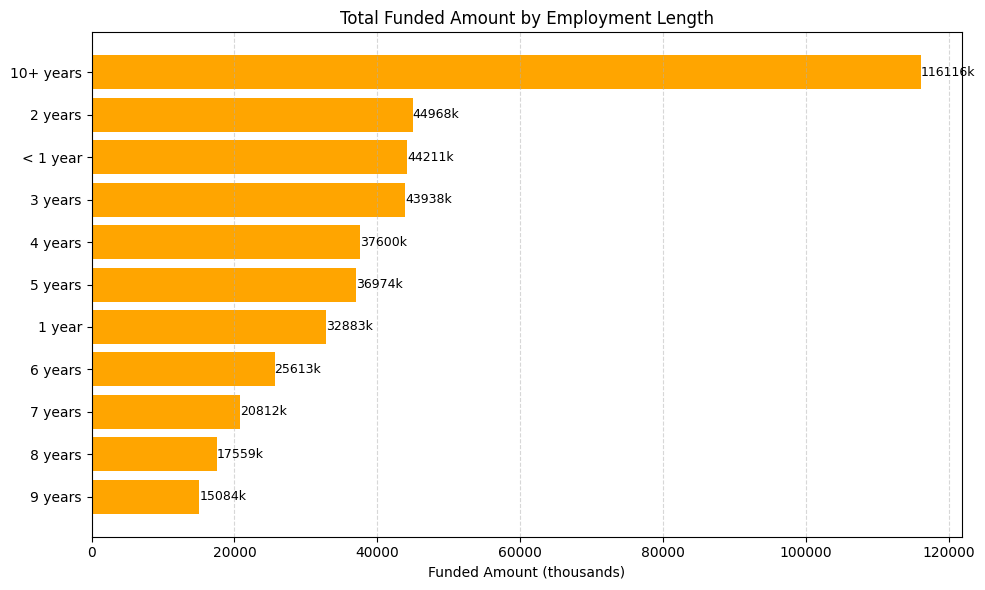

In [ ]:
emp_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_funding.index, emp_funding, color='orange')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}k',
             va='center',
             fontsize=9)

plt.xlabel('Funded Amount (thousands)')
plt.title('Total Funded Amount by Employment Length')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




### **Employee Length by Total Amount Received** ###

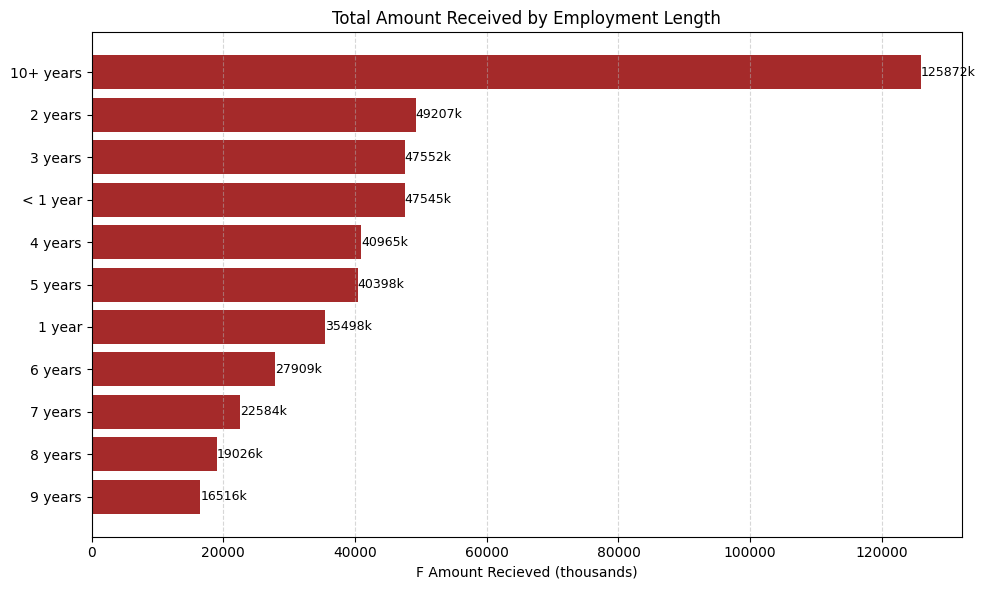

In [39]:
emp_Amount_Recieved = df.groupby('emp_length')['total_payment'].sum().sort_values() / 1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_Amount_Recieved .index, emp_Amount_Recieved , color='brown')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}k',
             va='center',
             fontsize=9)

plt.xlabel('F Amount Recieved (thousands)')
plt.title('Total Amount Received by Employment Length')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

 ### **Employee Length by Total Loan Application** ###

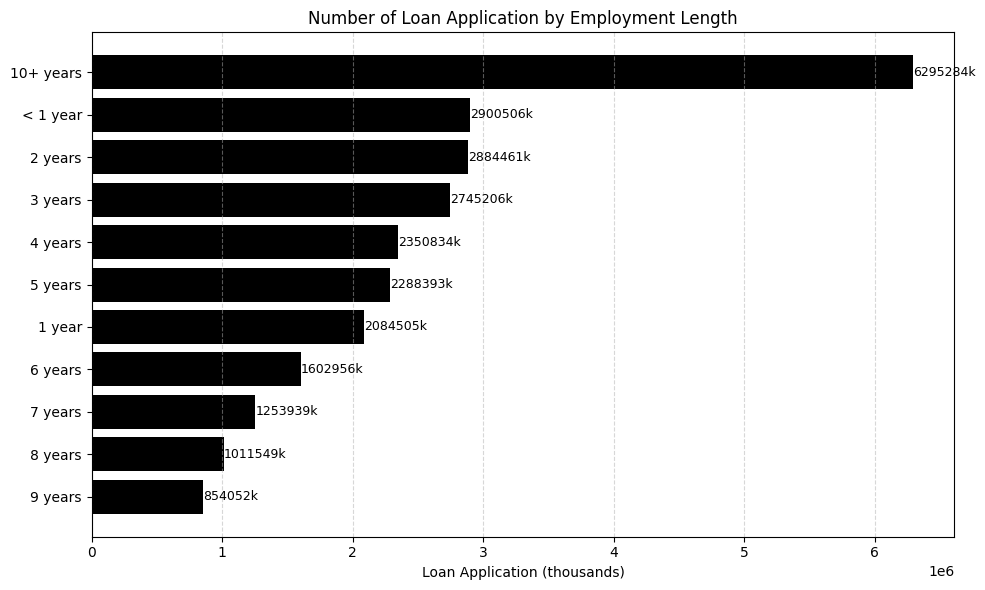

In [40]:
emp_Loan_Application = df.groupby('emp_length')['id'].sum().sort_values() / 1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_Loan_Application.index, emp_Loan_Application, color='black')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}k',
             va='center',
             fontsize=9)

plt.xlabel('Loan Application (thousands)')
plt.title('Number of Loan Application by Employment Length')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Loan Purpose by Total Funded Amount**

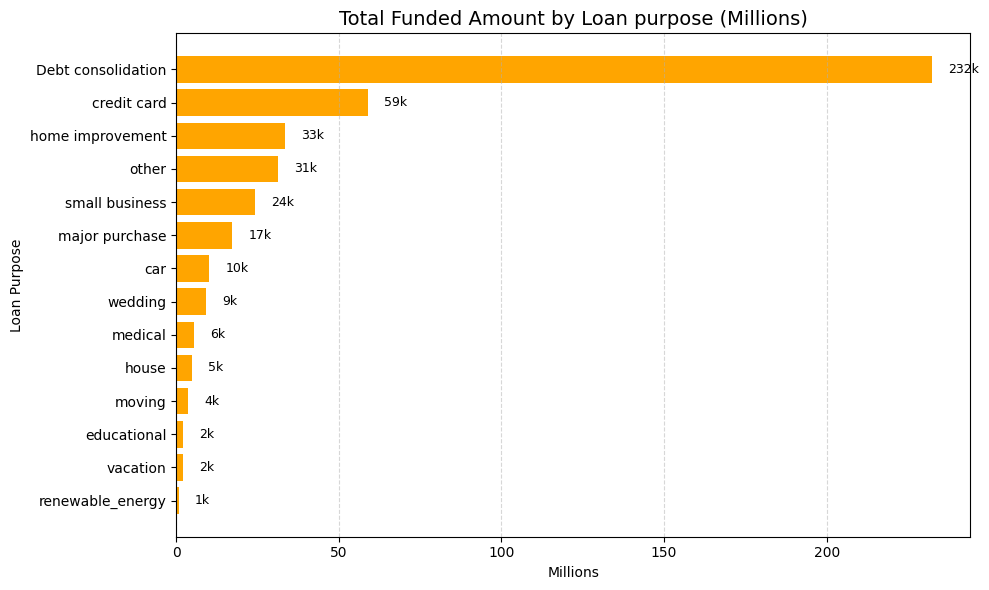

In [ ]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values() / 1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_funding_millions.index, purpose_funding_millions, color='orange')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}k',
             va='center',
             fontsize=9)
plt.xlabel('Millions')
plt.title('Total Funded Amount by Loan purpose (Millions)',fontsize = 14)
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Loan Purpose by Total Amount Recieved** ###

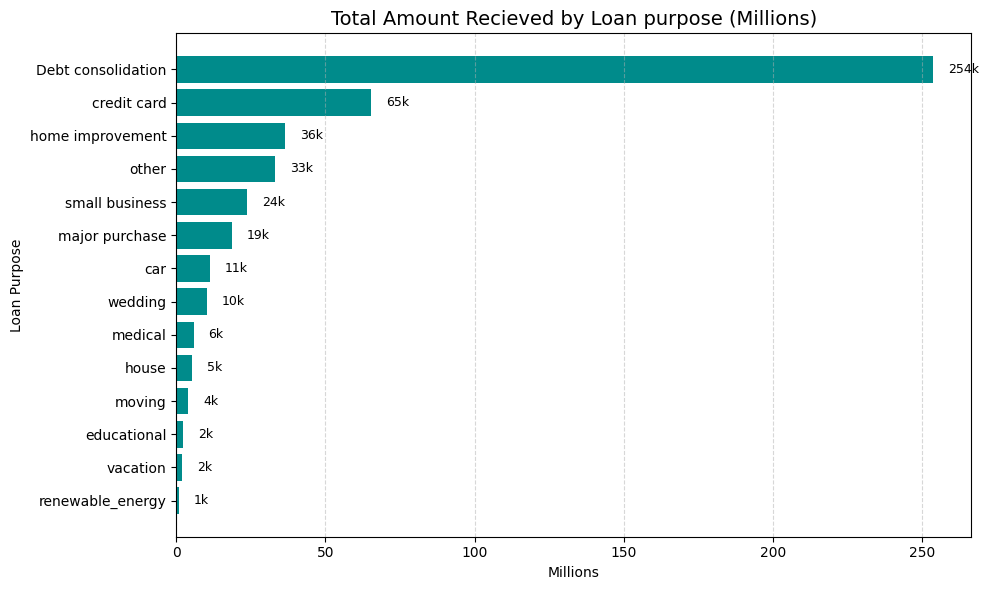

In [45]:
purpose_Amount_Recieved_millions = (df.groupby('purpose')['total_payment'].sum().sort_values() / 1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_Amount_Recieved_millions.index, purpose_Amount_Recieved_millions, color='darkcyan')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}k',
             va='center',
             fontsize=9)
plt.xlabel('Millions')
plt.title('Total Amount Recieved by Loan purpose (Millions)',fontsize = 14)
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Loan Purpose by Total Loan Application** ###

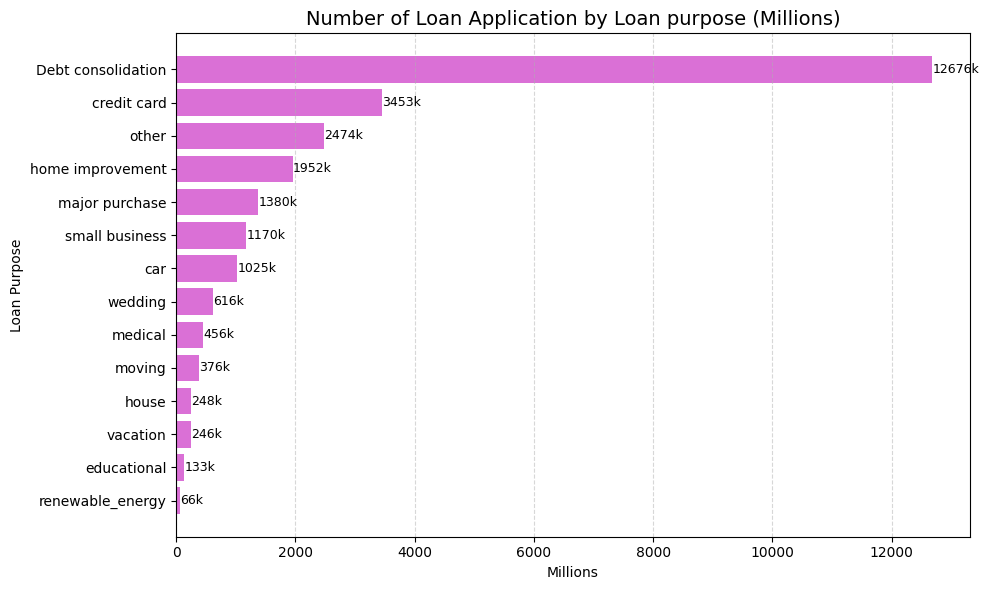

In [46]:
purpose_Loan_Application_millions = (df.groupby('purpose')['id'].sum().sort_values() / 1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_Loan_Application_millions.index, purpose_Loan_Application_millions, color='orchid')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}k',
             va='center',
             fontsize=9)
plt.xlabel('Millions')
plt.title('Number of Loan Application by Loan purpose (Millions)',fontsize = 14)
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Home Ownership by Total Funded Amount**

In [ ]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding ['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path = ['home_ownership'],
    values = 'loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale = "blues",
    title = 'Total Funded Amount by Home Ownership (Millions)'
)
fig.show()

### **Home Ownership by Total Amount Recieved** ###

In [51]:
home_A_Received = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_A_Received ['loan_amount_millions'] = home_A_Received['loan_amount'] / 1000000

fig = px.treemap(
    home_A_Received,
    path = ['home_ownership'],
    values = 'loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale = "rainbow",
    title = 'Total Amount Recieved by Home Ownership (Millions)'
)
fig.show()

### **Home Ownership by Total Loan Application** ###

In [53]:
home_l_Application = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_l_Application ['loan_amount_millions'] = home_l_Application['loan_amount'] / 1000000

fig = px.treemap(
    home_l_Application,
    path = ['home_ownership'],
    values = 'loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale = "balance",
    title = 'Total Loan Application by Home Ownership (Millions)'
)
fig.show()